In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import Binarizer
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import PowerTransformer

### This dataset is originally from the National Institute of Diabetes and Digestive and Kidney
Diseases. The objective of the dataset is to diagnostically predict whether a patient has diabetes,
based on certain diagnostic measurements included in the dataset. Several constraints were placed
on the selection of these instances from a larger database. In particular, all patients here are females
at least 21 years old of Pima Indian heritage.2
From the data set in the (.csv) File We can find several variables, some of them are independent
(several medical predictor variables) and only one target dependent variable (Outcome).  
###

In [3]:
df = pd.read_csv('diabetes.csv')
df.head(10)

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1
5,5,116,74,0,0,25.6,0.201,30,0
6,3,78,50,32,88,31.0,0.248,26,1
7,10,115,0,0,0,35.3,0.134,29,0
8,2,197,70,45,543,30.5,0.158,53,1
9,8,125,96,0,0,0.0,0.232,54,1


In [4]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
Pregnancies,768.0,3.845052,3.369578,0.000,1.00000,3.0000,6.00000,17.00
Glucose,768.0,120.894531,31.972618,0.000,99.00000,117.0000,140.25000,199.00
BloodPressure,768.0,69.105469,19.355807,0.000,62.00000,72.0000,80.00000,122.00
SkinThickness,768.0,20.536458,15.952218,0.000,0.00000,23.0000,32.00000,99.00
Insulin,768.0,79.799479,115.244002,0.000,0.00000,30.5000,127.25000,846.00
BMI,768.0,31.992578,7.884160,0.000,27.30000,32.0000,36.60000,67.10
DiabetesPedigreeFunction,768.0,0.471876,0.331329,0.078,0.24375,0.3725,0.62625,2.42
Age,768.0,33.240885,11.760232,21.000,24.00000,29.0000,41.00000,81.00
Outcome,768.0,0.348958,0.476951,0.000,0.00000,0.0000,1.00000,1.00


Index(['Pregnancies', 'Glucose', 'BloodPressure', 'SkinThickness', 'Insulin',
       'BMI', 'DiabetesPedigreeFunction', 'Age'],
      dtype='object')


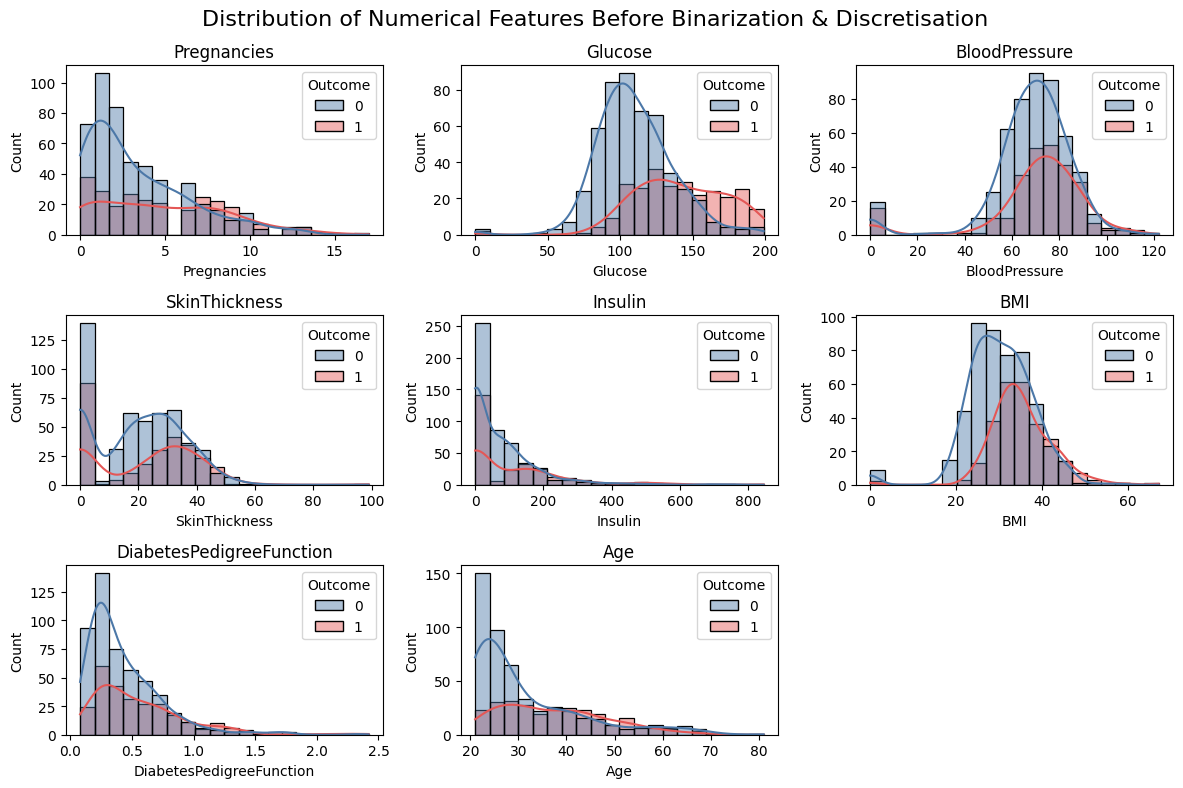

In [5]:
num_cols = df.select_dtypes(include=np.number).columns.drop("Outcome", errors="ignore")
plt.figure(figsize=(12, 8))

plt.suptitle('Distribution of Numerical Features Before Binarization & Discretisation', fontsize=16)
print(num_cols)

outcome_palette = {0: "#4C78A8", 1: "#E45756"}

for i, col in enumerate(num_cols):
    plt.subplot(3, 3, i + 1)
    sns.histplot(
        data=df,
        x=col,
        hue="Outcome",
        bins=20,
        kde=True,
        alpha=0.45,
        palette=outcome_palette,
        multiple="layer",
    )
    plt.title(col)

plt.tight_layout()
plt.show()

In [6]:
## Distribution of target variable
X = df.drop('Outcome', axis=1)
y = df['Outcome']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)


## Applying the DecisionTreeClassifier before applying any Feature Engg ##

In [7]:
clf = DecisionTreeClassifier(random_state=42)
clf.fit(X_train, y_train)
y_pred = clf.predict(X_test)
print(classification_report(y_test, y_pred))
print(confusion_matrix(y_test, y_pred))
print("Accuracy before binarization: ", accuracy_score(y_test, y_pred))


              precision    recall  f1-score   support

           0       0.83      0.76      0.79        99
           1       0.62      0.73      0.67        55

    accuracy                           0.75       154
   macro avg       0.73      0.74      0.73       154
weighted avg       0.76      0.75      0.75       154

[[75 24]
 [15 40]]
Accuracy before binarization:  0.7467532467532467


In [8]:
## Using the cross validation score to get a better estimate of the model performance
cv_scores = cross_val_score(clf, X, y, cv=5, scoring='accuracy')
print("Cross Validation Scores: ", cv_scores)
print("Mean CV Score: ", cv_scores.mean())

Cross Validation Scores:  [0.71428571 0.66233766 0.64935065 0.81045752 0.74509804]
Mean CV Score:  0.7163059163059163


## Now Applying the Feature Engg to make the Accuracy score ##

In [9]:
## Applying Discretisation of the features using KBinsDiscretizer
from sklearn.preprocessing import KBinsDiscretizer
num_features = X.select_dtypes(include=np.number).columns
discretizer = KBinsDiscretizer(n_bins=20, encode='ordinal', strategy='quantile')
X_discretized_tr_raw = discretizer.fit_transform(X_train[num_features])
X_discretized_tr = pd.DataFrame(X_discretized_tr_raw, columns=num_features)

X_discretized_te_raw = discretizer.transform(X_test[num_features])
X_discretized_te = pd.DataFrame(X_discretized_te_raw, columns=num_features)

X_discretized_df = pd.concat([X_discretized_tr, X_discretized_te], axis=0, ignore_index=True)
y_discretized_df = pd.concat([y_train, y_test], axis=0, ignore_index=True)


C:\Users\lalan\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\LocalCache\local-packages\Python312\site-packages\sklearn\preprocessing\_discretization.py:296: FutureWarning: The current default behavior, quantile_method='linear', will be changed to quantile_method='averaged_inverted_cdf' in scikit-learn version 1.9 to naturally support sample weight equivalence properties by default. Pass quantile_method='averaged_inverted_cdf' explicitly to silence this warning.
  warnings.warn(
C:\Users\lalan\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\LocalCache\local-packages\Python312\site-packages\sklearn\preprocessing\_discretization.py:397: UserWarning: Bins whose width are too small (i.e., <= 1e-8) in feature 0 are removed. Consider decreasing the number of bins.
  warnings.warn(
C:\Users\lalan\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\LocalCache\local-packages\Python312\site-packages\sklearn\preprocessing\

### Plotting the Graphs of each column after Uniform Discretisation  ###

Index(['Pregnancies', 'Glucose', 'BloodPressure', 'SkinThickness', 'Insulin',
       'BMI', 'DiabetesPedigreeFunction', 'Age'],
      dtype='object')


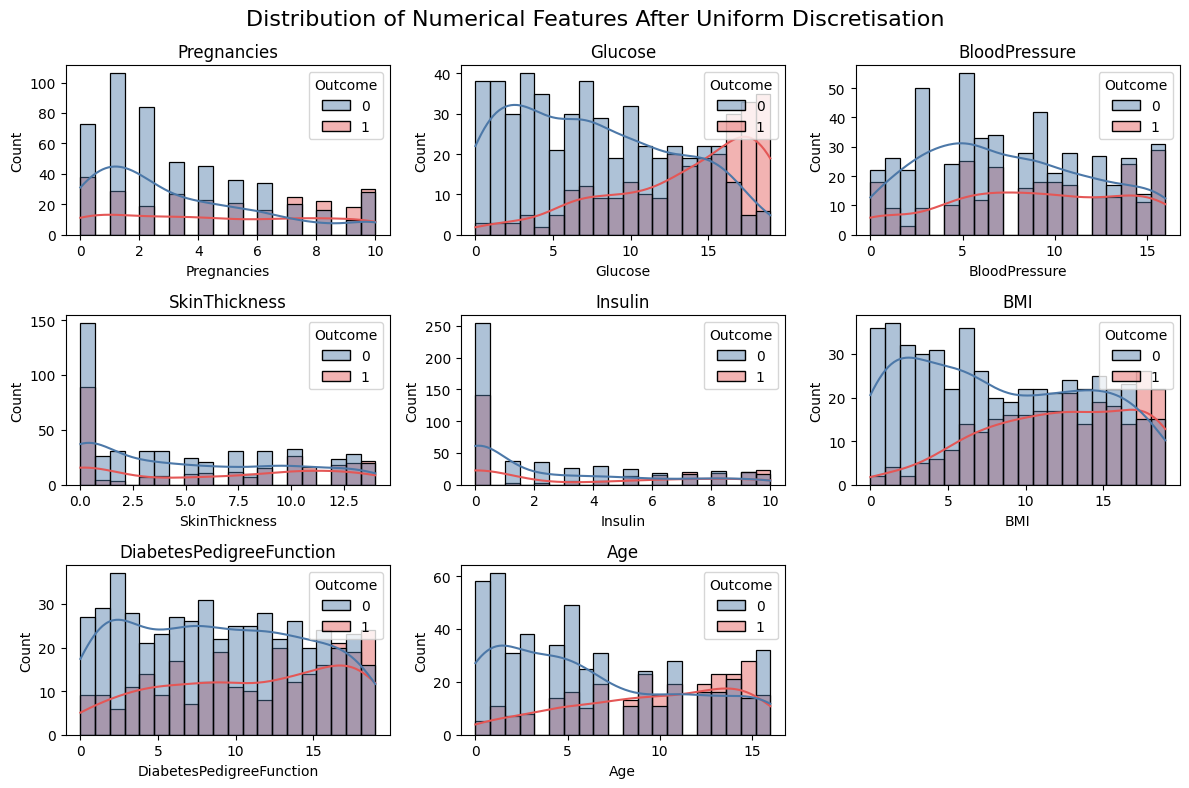

In [10]:
num_cols = X_discretized_df.select_dtypes(include=np.number).columns.drop("Outcome", errors="ignore")
plt.figure(figsize=(12, 8))

plt.suptitle('Distribution of Numerical Features After Uniform Discretisation', fontsize=16)
print(num_cols)

outcome_palette = {0: "#4C78A8", 1: "#E45756"}

for i, col in enumerate(num_cols):
    plt.subplot(3, 3, i + 1)
    sns.histplot(
        data=X_discretized_df,
        x=col,
        hue=y_discretized_df,
        bins=20,
        kde=True,
        alpha=0.45,
        palette=outcome_palette,
        multiple="layer",
    )
    plt.title(col)

plt.tight_layout()
plt.show()

### Applying Yeo-Johnson ###

In [ ]:
pt_yeo_johnson = PowerTransformer(method='yeo-johnson',standardize=True, copy=False)
X_yeo_tr_raw = pt_yeo_johnson.fit_transform(X_train[num_features])
X_yeo_tr = pd.DataFrame(X_yeo_tr_raw, columns=num_features)

X_yeo_te_raw = pt_yeo_johnson.transform(X_test[num_features])
X_yeo_te = pd.DataFrame(X_yeo_te_raw, columns=num_features)

X_pt = pd.concat([X_yeo_tr, X_yeo_te], axis=0, ignore_index=True)
y_pt = pd.concat([y_train, y_test], axis=0, ignore_index=True)



## Plotting the plot ##

Index(['Pregnancies', 'Glucose', 'BloodPressure', 'SkinThickness', 'Insulin',
       'BMI', 'DiabetesPedigreeFunction', 'Age'],
      dtype='object')


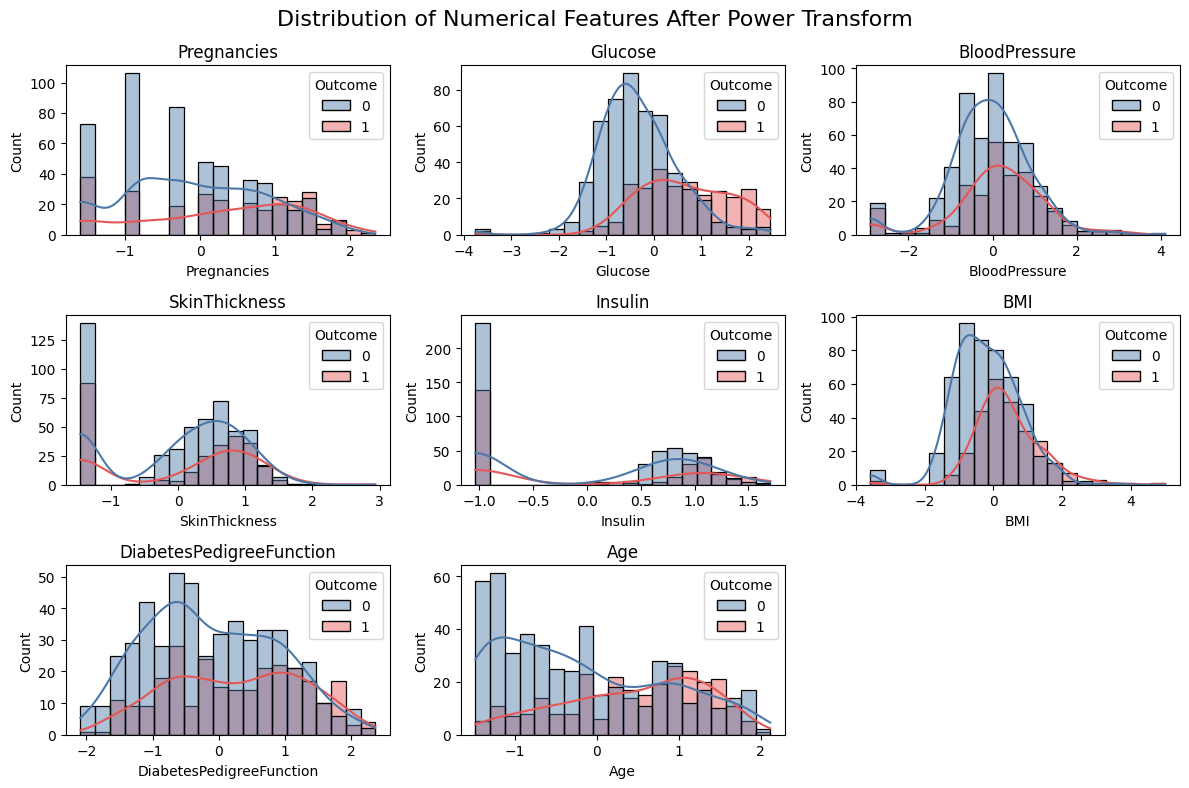

In [12]:
num_cols = X_pt.select_dtypes(include=np.number).columns.drop("Outcome", errors="ignore")
plt.figure(figsize=(12, 8))

plt.suptitle('Distribution of Numerical Features After Power Transform', fontsize=16)
print(num_cols)

outcome_palette = {0: "#4C78A8", 1: "#E45756"}

for i, col in enumerate(num_cols):
    plt.subplot(3, 3, i + 1)
    sns.histplot(
        data=X_pt,
        x=col,
        hue=y_pt,
        bins=20,
        kde=True,
        alpha=0.45,
        palette=outcome_palette,
        multiple="layer",
    )
    plt.title(col)

plt.tight_layout()
plt.show()

In [14]:
from sklearn.preprocessing import MinMaxScaler


discretizer = KBinsDiscretizer(n_bins=20, encode='ordinal', strategy='quantile')
num_features = X.select_dtypes(include=np.number).columns
ct = ColumnTransformer([("discretizer", discretizer, num_features),("yeo_johnson", PowerTransformer(method='yeo-johnson'), num_features),("minmax", MinMaxScaler(), num_features)], remainder="passthrough")
pipeline = Pipeline([("preprocessor", ct), ("classifier", DecisionTreeClassifier(random_state=42))])
pipeline.fit(X_train, y_train)
y_pred_discretized = pipeline.predict(X_test)
print(classification_report(y_test, y_pred_discretized))
print(confusion_matrix(y_test, y_pred_discretized))
print("Accuracy after discretization: ", accuracy_score(y_test, y_pred_discretized))


              precision    recall  f1-score   support

           0       0.84      0.77      0.80        99
           1       0.63      0.73      0.68        55

    accuracy                           0.75       154
   macro avg       0.74      0.75      0.74       154
weighted avg       0.76      0.75      0.76       154

[[76 23]
 [15 40]]
Accuracy after discretization:  0.7532467532467533


C:\Users\lalan\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\LocalCache\local-packages\Python312\site-packages\sklearn\preprocessing\_discretization.py:296: FutureWarning: The current default behavior, quantile_method='linear', will be changed to quantile_method='averaged_inverted_cdf' in scikit-learn version 1.9 to naturally support sample weight equivalence properties by default. Pass quantile_method='averaged_inverted_cdf' explicitly to silence this warning.
  warnings.warn(
C:\Users\lalan\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\LocalCache\local-packages\Python312\site-packages\sklearn\preprocessing\_discretization.py:397: UserWarning: Bins whose width are too small (i.e., <= 1e-8) in feature 0 are removed. Consider decreasing the number of bins.
  warnings.warn(
C:\Users\lalan\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\LocalCache\local-packages\Python312\site-packages\sklearn\preprocessing\